# COMP90086 Workshop 5

***
In this worksheet, we'll implement a convolutional neural network (CNN) in Keras—a high-level API for deep learning. We will use MNIST Dataset for experiments.


Table of Contents
- Exercise: CNN parameters
- Visualize Filters and Feature Maps in CNN
- Convolutional neural network with depthwise separable convolution
- Apply Deep CNN for feature extraction  

### Exercise 1

In the following CNN network, the input is a RGB image with values in the range 0-255. The convolution operation in the convolutional layers (A,B) are standard 2D convolution (i.e., each kernel has the same number of channels of the input, and the kernel goes through local patches of the input to conduct element-wise multiplication and then sum). Each convolutional layer uses a ReLU activation function. The final layer (D) is a fully connected layer with 10 units.

![CNN](https://raw.githubusercontent.com/saraao/COMP90086_image/main/cnn.png)

i) What is the total number of parameters in this network? Show your work.

ii) Suppose you initialise this network so that all parameters are equal to zero. If you run an image through this network, what will be the output of layer B? Give the dimensions of this output and a description of the values you would expect.

iii) Now suppose you initialise this network so that all weights are equal to 1 and all biases equal to 0. If you run an image through this network, what is the output of layer B? Describe what you would expect this layer's output to look like.

iv) How could you reduce the number of parameters in this network without reducing the number of filters or their effective kernel size?

Output Size:
- A (22,22,20)
- B (20,20,40)
- C (10,10,40)

### Exercise 1 Answer:

i)  A : 5 * 5* 20 *3 + 20 (bias) = 1520 parameters, output of size (22,22,20).

B : 3  *3 *20 * 40 + 40 (bias) = 7240 parameters, output of size (20,20,40).

C : 0 parameters,  output of size (10,10,40)

D : 4000*10 +10 (bias)  = 40010 parameters.

In total of 1520 + 7240 + 40010 = 48770 parameters

ii) The output would be 20 x 20 x 40, all zeros.

iii) The output would be a **stack of blurry versions** of the input (both conv layers are initialised as averaging filters).

iv) Options:

•	Replace the conv layers with **separable convolution**

•	Replace the 5x5 layer with **stacked convolution**

## 1. Visualize Filters and Feature Maps in CNN

We will discover how to develop simple visualizations for filters and feature maps in a CNN. We'll be using the [VGG16 model](https://keras.io/api/applications/vgg/#vgg16-function) provided by Keras, trained on the ImageNet dataset. For more information on the VGG16, see the [paper](https://arxiv.org/abs/1409.1556).

This section draws heavily on [Jason Brownlee](https://machinelearningmastery.com/)‘s work.

In [1]:
# Imports
from datetime import datetime
from packaging import version

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import Model

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# you may want to keep logging enabled when doing your own work
# disable Tensorflow warnings for this tutorial
import logging
tf.get_logger().setLevel(logging.ERROR)
# disable Keras warnings for this tutorial
import warnings
warnings.simplefilter("ignore")

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


### Load a VGG16 model loaded with pre-trained ImageNet weights

If this is the first time that you have loaded the model, the weights will be downloaded from the internet and may take a moment to download depending on the speed of your internet connection.

In [2]:
from tensorflow.keras.applications.vgg16 import VGG16

# load the model
model = VGG16()
# summarize the model
model.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

Now that we have a pre-trained model, we can use it as the basis for visualizations.

### Visualize Filters

#### Summarize the model filters
We can access all of the layers of the model via the `model.layers` property.

Each layer has a `layer.name` property, where the convolutional layers have a naming convolution like `block#_conv#`, where the `#` is an integer. Therefore, we can check the name of each layer and skip any that don’t contain the string `conv`.

Each convolutional layer has two sets of weights. One is the block of filters and the other is the block of bias values. These are accessible via the `layer.get_weights()` function. We can retrieve these weights and then summarize their shape.

In [4]:
# summarize filter shapes
for layer in model.layers:
    # check for convolutional layer
    if 'conv' not in layer.name:
        continue
    # get filter weights
    filters, biases = layer.get_weights()
    print(layer.name, filters.shape, biases.shape)

block1_conv1 (3, 3, 3, 64) (64,)
block1_conv2 (3, 3, 64, 64) (64,)
block2_conv1 (3, 3, 64, 128) (128,)
block2_conv2 (3, 3, 128, 128) (128,)
block3_conv1 (3, 3, 128, 256) (256,)
block3_conv2 (3, 3, 256, 256) (256,)
block3_conv3 (3, 3, 256, 256) (256,)
block4_conv1 (3, 3, 256, 512) (512,)
block4_conv2 (3, 3, 512, 512) (512,)
block4_conv3 (3, 3, 512, 512) (512,)
block5_conv1 (3, 3, 512, 512) (512,)
block5_conv2 (3, 3, 512, 512) (512,)
block5_conv3 (3, 3, 512, 512) (512,)


How to intepret the value?
filters ( kernel width, kernel height, num_channel, num_filter)

We can see that all convolutional layers use 3×3 filters.

We can see that for the input image with three channels for red, green and blue, each filter has a depth of three (here we are working with a **channel-last format**). We could visualize one filter as a plot with three images, one for each channel, or compress all three down to a single colour image, or even just look at the first channel and assume the other channels will look the same. The problem is that we have 63 other filters we might like to visualize.

We can retrieve the filters from the first layer as follows:

In [5]:
# retrieve weights from the second hidden layer
filters, biases = model.layers[1].get_weights()

The weight values will likely be small positive and negative values centered around 0.0.

We can normalize their values to the range 0-1 to make them easy to visualize.

In [6]:
# normalize filter values to 0-1 so we can visualize them
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

We will be visualising the first six filters out of 64 filters from 1st layer, and plot each of the three channels of each filter. One row for each filter and one column for each channel.

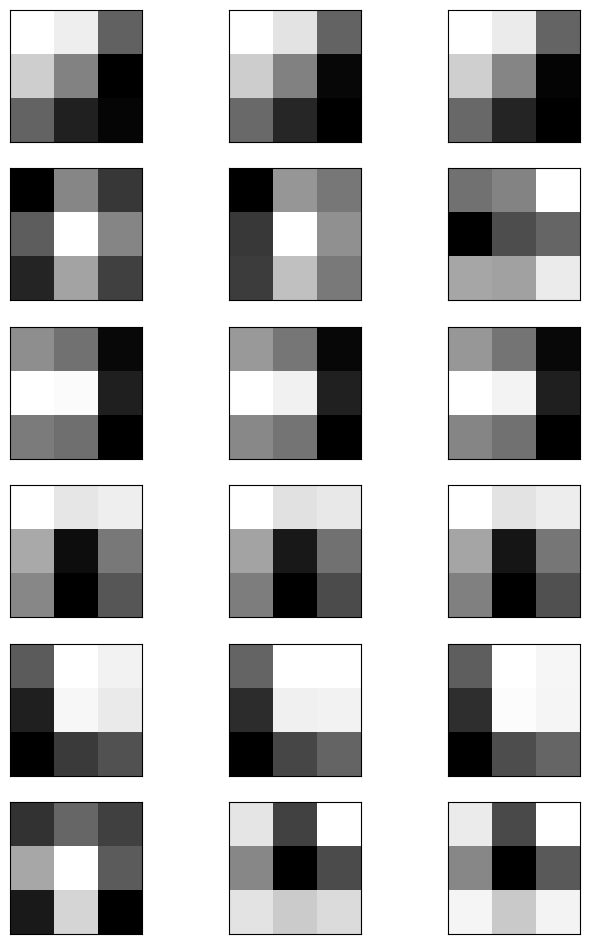

In [7]:
# plot first few filters
n_filters, ix = 6, 1

fig = plt.figure(figsize=(8, 12))
for i in range(n_filters):
    # get the filter
    f = filters[:, :, :, i]
    # plot each channel separately
    for j in range(3):
        # subplot for 6 filters and 3 channels
        # specify subplot and turn of axis
        ax = plt.subplot(n_filters, 3, ix)
        ax.set_xticks([])
        ax.set_yticks([])
        # plot filter channel in grayscale
        plt.imshow(f[:, :, j], cmap='gray')
        ix += 1
# plot the filters
plt.show()

We can see that in some cases, the filter is the same across the channels (the first row), and in others, the filters differ (the last row).

The dark squares indicate small or inhibitory weights and the light squares represent large or excitatory weights. Using this intuition, we can see that the filters on the first row detect a gradient from light in the top left to dark in the bottom right.


### Visualize Feature Maps

The activation maps, called feature maps, capture the result of applying the filters to input, such as the input image or another feature map.

We need a clearer idea of the shape of the feature maps output by each of the convolutional layers and the layer index number so that we can retrieve the appropriate layer output. The block below will enumerate all layers in the model and print the output size or feature map size for each convolutional layer as well as the layer index in the model.

In [8]:
# summarize feature map shapes
for i in range(len(model.layers)):
    layer = model.layers[i]
    # check for convolutional layer
    if 'conv' not in layer.name:
        continue
    # summarize output shape
    print(i, layer.name, layer.output.shape)

1 block1_conv1 (None, 224, 224, 64)
2 block1_conv2 (None, 224, 224, 64)
4 block2_conv1 (None, 112, 112, 128)
5 block2_conv2 (None, 112, 112, 128)
7 block3_conv1 (None, 56, 56, 256)
8 block3_conv2 (None, 56, 56, 256)
9 block3_conv3 (None, 56, 56, 256)
11 block4_conv1 (None, 28, 28, 512)
12 block4_conv2 (None, 28, 28, 512)
13 block4_conv3 (None, 28, 28, 512)
15 block5_conv1 (None, 14, 14, 512)
16 block5_conv2 (None, 14, 14, 512)
17 block5_conv3 (None, 14, 14, 512)


We can use this information and design a new model that is a subset of the layers in the full VGG16 model. The model would have the same input layer as the original model, but the output would be the output of a given convolutional layer, which we know would be the activation of the layer or the feature map.

For example, after loading the VGG model, we can define a new model that outputs a feature map from the first convolutional layer (index 1) as follows.

In [9]:
# redefine model to output right after the first hidden layer
model = Model(inputs=model.inputs, outputs=model.layers[1].output)

After defining the model, we need to load the image with the size expected by the model, in this case, 224×224.

### Exercise 2: Try replacing it with the image of your choice
Download your favourite photo and place it in your current working directory with the filename `harry.png`.

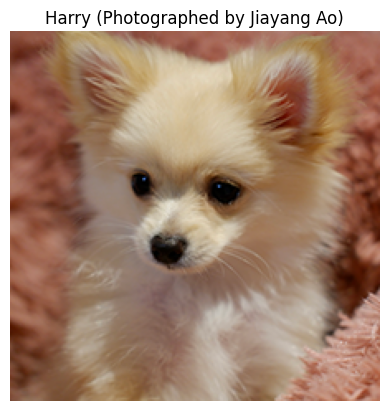

before expanding dimension:  (224, 224, 3)
after expanding dimension:  (1, 224, 224, 3)


In [13]:
# load the image with the required shape
img = load_img('./harry.png', target_size=(224, 224))

plt.imshow(img)
plt.title("Harry (Photographed by Jiayang Ao)")
plt.axis('off')
plt.show()

# convert the image to an array
img = img_to_array(img)

print("before expanding dimension: ", img.shape)
# expand dimensions so that it represents a single 'sample'
img = np.expand_dims(img, axis=0)
print("after expanding dimension: ", img.shape)
# prepare the image (e.g. scale pixel values for the vgg)
img = preprocess_input(img)

We are now ready to get the feature map. We can do this easy by calling the `model.predict()` function and passing in the prepared single image.

We know the result will be a feature map with 224x224x64. We can plot all 64 two-dimensional images as an 8×8 square of images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step


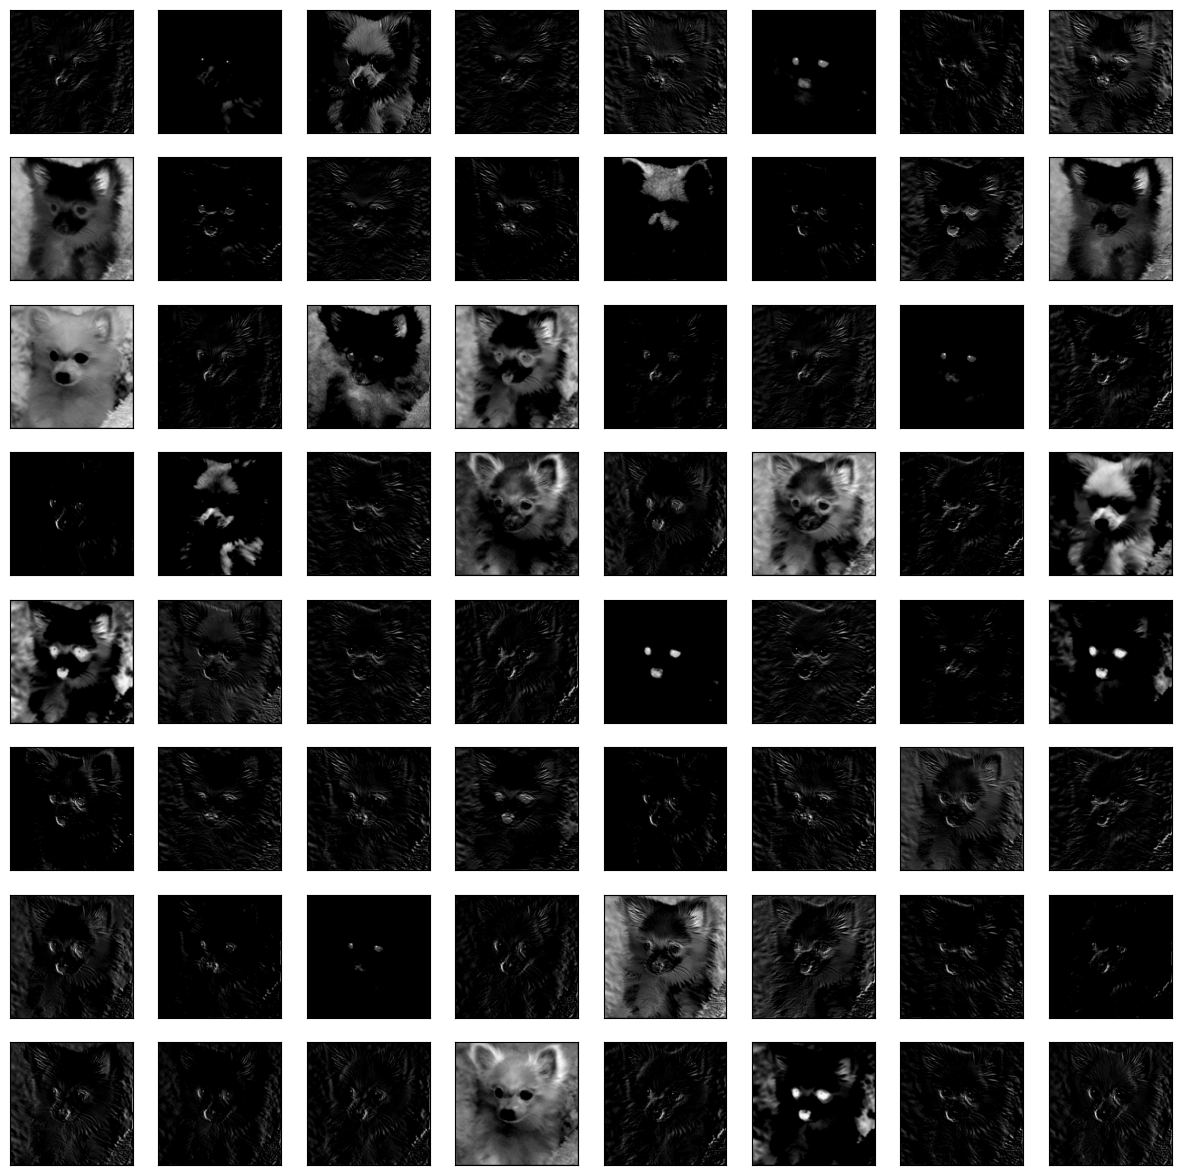

In [14]:
# get feature map for first hidden layer
feature_maps = model.predict(img)


fig = plt.figure(figsize=(15,15))
# plot all 64 maps in an 8x8 squares
square = 8
for i in range(1, square*square+1):
    # specify subplot and turn of axis
    ax = plt.subplot(square,square,i)
    ax.set_xticks([])
    ax.set_yticks([])
    # plot feature maps in grayscale
    plt.imshow(feature_maps[0,:,:,i-1] , cmap='gray')

# plot all feature maps
plt.show()

## 2 Convolutional neural network with depthwise separable convolution

### Exercise 3

Construct a CNN with the previous architecture (same output size of feature maps in each layer), except that the standard 2D convolution is replaced  with depthwise separable convolution

Complete the code block below to instantiate the model in Keras.

***Hint: check keras documents for usages of the layers, e.g., how to set the hyperparameters.***

- SeparableConv2D layer: [layers.SeparableConv2D](https://keras.io/api/layers/convolution_layers/separable_convolution2d/)


In [15]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()
print("train_images shape:", train_images.shape)
print("test_images shape:", test_images.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
train_images shape: (60000, 28, 28)
test_images shape: (10000, 28, 28)


In [16]:
# Data type adjustment & rescale
train_images = train_images.astype(float) / 255 #scale the pixel values to be 0-1
test_images = test_images.astype(float) / 255

In [17]:
cnn_ds = keras.Sequential(
    [
        layers.Input((28, 28, 1)),
        layers.SeparableConv2D( 8,(5, 5),activation='relu'), # fill in
        layers.MaxPooling2D((2, 2)), # fill in
        layers.SeparableConv2D(16,(5, 5),  activation='relu'), #fill in
        layers.MaxPooling2D((2, 2)), # fill in


        layers.Flatten(),
        layers.Dense(10, activation='softmax')
    ],
)

Compile and training as before

In [18]:
cnn_ds.compile(optimizer='adam',
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
            metrics=['accuracy'])

history_cnn_ds = cnn_ds.fit(train_images, train_labels, epochs=5, batch_size=100, validation_split=0.2)

Epoch 1/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.6423 - loss: 1.2104 - val_accuracy: 0.9361 - val_loss: 0.2229
Epoch 2/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.9342 - loss: 0.2242 - val_accuracy: 0.9511 - val_loss: 0.1709
Epoch 3/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - accuracy: 0.9537 - loss: 0.1583 - val_accuracy: 0.9609 - val_loss: 0.1339
Epoch 4/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - accuracy: 0.9616 - loss: 0.1276 - val_accuracy: 0.9653 - val_loss: 0.1196
Epoch 5/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - accuracy: 0.9659 - loss: 0.1122 - val_accuracy: 0.9683 - val_loss: 0.1075


We can get a useful summary, including output shape and number of parameters  of the model architecture using the `summary` method, as shown below.
* Try to  compute the parameters of each layer yourself. Note that if you donot count bias, there could be some difference compare with the summary output number (with bias in a layer, the additional NO. parameters is the NO. filters in the layer).

In [19]:
cnn_ds.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv2d                │ (None, 24, 24, 8)      │            41 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 8, 8, 16)       │           344 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,867 (34.64 KB)

 Trainable params: 2,955 (11.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,912 (23.10 KB)

* Separable_conv2d: $5  \times 5 \times 1 + 1\times 1\times 1\times 8 +8 $ (Depthwise convolution: Each 5x5 kernel iterates 1 channel of the image; Pointwise Convolution: uses 8 1x1 kernel).
* Separable_conv2d_later: $5  \times 5 \times 8 + 1\times 1\times 8 \times 16 + 16 $ (Depthwise convolution: Each 5x5 kernel iterates 8 channel of the image; Pointwise Convolution: uses 16 1x1x8 kernel).
* Dense: $256 \times 10 + 10$ (Flatten image and feed to fully connected layer w/ 10 output classes)
* Total params: $41+344+2570=2955$

**Depthwise Convolution (Spatial Filtering):** A single 5x5 filter is applied to each input channel independently.

- Calculation: (filter_height × filter_width × channels)

**Pointwise Convolution (Channel Combination):** 1x1 convolutions are used to combine the outputs of the depthwise step into the desired number of output channels.

- Calculation: (1 × 1 × input_channels × output_channels) + output_channels_biases

***
**Question:** How does  `cnn_ds` model compare with  the earlier `cnn` model in terms of number of parameters and testing accuracy ?
***



The NO. parameters in  `cnn_ds`  is smaller than `cnn`, and the accuracies are similar.

Note: **the running time of `cnn_ds` is larger.** The efficiency of separable convolution is more obvious with large kernel sizes and more input channels,  because of the overhead involving doing separable convolution and pointwise convolution might be larger than the speedups.

## 3 Use Deep CNN for feature extraction

We will load a deep model, i.e., [ResNet50](https://arxiv.org/abs/1512.03385), to conduct prediction on some example images. The ResNet architecture was developed in 2015 and introduced *residual connections* - which replaces the standard parametric transform at each layer:

$$ \mathbf{x}_{l+1} = F_{\theta_l}(\mathbf{x}_l) $$

with a transformation of the rough form:

$$ \mathbf{x}_{l +1} = \varphi\left( \mathbf{x}_l + F_{\theta_l}(\mathbf{x}_l)\right), \, \varphi \, \text{some nonlinearity.}$$

The intuition here is that it is a more straightforward task for the network to learn the *residual*, which is the difference between the desired output (or desired mapping) and the input. The mathematical formulation could be expressed as F(x)=H(x)−x, where H(x) is the desired mapping, x is the input, and F(x) is the residual function that the network learns.


### Load Deep CNN
Load the ResNet50 with weights pre-trained on ImageNet.

Note that we only go up to the last convolutional layer --we don't include fully-connected layers by setting `include_top=False`. The reason is that adding the fully connected layers forces you to use a fixed input size for the model (224x224, the original ImageNet format). By only keeping the convolutional modules, our model can be adapted to arbitrary input sizes.

In [20]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Build a ResNet50 model loaded with pre-trained ImageNet weights
# we can set the input size to be the size of the input image (not necessarily 224x224)
base_model = ResNet50(weights='imagenet', input_shape=[128,128,3],include_top=False)
img_size = (128,128) # default input shape has to be (224, 224, 3)

# Print the names of layers
for idx in range(len(base_model.layers)):
    print(base_model.get_layer(index = idx).name)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
input_layer_2
conv1_pad
conv1_conv
conv1_bn
conv1_relu
pool1_pad
pool1_pool
conv2_block1_1_conv
conv2_block1_1_bn
conv2_block1_1_relu
conv2_block1_2_conv
conv2_block1_2_bn
conv2_block1_2_relu
conv2_block1_0_conv
conv2_block1_3_conv
conv2_block1_0_bn
conv2_block1_3_bn
conv2_block1_add
conv2_block1_out
conv2_block2_1_conv
conv2_block2_1_bn
conv2_block2_1_relu
conv2_block2_2_conv
conv2_block2_2_bn
conv2_block2_2_relu
conv2_block2_3_conv
conv2_block2_3_bn
conv2_block2_add
conv2_block2_out
conv2_block3_1_conv
conv2_block3_1_bn
conv2_block3_1_relu
conv2_block3_2_conv
conv2_block3_2_bn
conv2_block3_2_relu
conv2_block3_3_conv
conv2_block3_3_bn
conv2_block3_add
conv2_block3_out
conv3_block1_1_conv
conv3_block1_1_bn
conv3_block1_1_relu
conv3_block1_2_conv
conv3_block1_2_bn
conv3_block1_2_relu
conv3_block1_0_conv
conv3_block1_3_conv
conv3_block1_0_bn
conv3_block1_3_bn
conv3_block1_add
conv3_block1_out
conv3_block2_1_conv
conv3_block2_1_bn
conv3_b

### Exercise 4: Use Pre-trained deep CNN for feature extraction

Use the above pre-trained model to extract feature from the image. Use the output of the "conv3_block4_out" layer as the feature output.

***Hint: create a model with `base_model.input` as the intput and the output of the `"conv3_block4_out"` as the output, then processs the input, and conduct prediction using `model.predict`.***


In [21]:
# Define a function to process the input image
def get_img_array(img_path, size):
    # `img` is a PIL image of size 224x224
    img = image.load_img(img_path, target_size=size)
    # Convert the image pixels to a numpy array
    # if size is (224,224), `array` is a float32 Numpy array of shape (224, 224, 3)
    array = image.img_to_array(img)
    # Reshape data for the model
    # We add a dimension to transform our array into a "batch" of size (1, 224, 224, 3)
    # Convert the input to 4D input makes it the same as the training process,
    # with a placeholder, rows, cols, the number of colour channels as training process
    array = np.expand_dims(array, axis=0)
    # axis: Position in the expanded axes where the new axis (or axes) is placed.
    # axis = 0: insert axis at position 0
    return array

In [22]:
## your code

# Extract features from an arbitrary intermediate layer with VGG19
model = Model(inputs=base_model.input, outputs=base_model.get_layer('conv3_block4_out').output)

# Prepare image for the model
img_name = 'wallaby.jpeg'
x = preprocess_input(get_img_array(img_name, size=(128, 128)))

features = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 852ms/step


In [23]:
print(features.shape)

(1, 16, 16, 512)
